# Laboratorio 1 — Exploración, preparación y regresión lineal

**Curso:** ISIS2611  
**Integrantes:** [Nombre 1] — [Nombre 2]  
**Bloque Neón:** [Bloque]  
**Fecha:** [Fecha]

> **Propósito:** predecir la temperatura máxima del día siguiente e identificar las variables meteorológicas que más contribuyen a dicha predicción.

## Tabla de contenido

1. Comprensión del problema y los datos
2. Configuración del entorno
3. Carga de datos
4. Exploración de datos
5. Evaluación de la calidad de los datos
6. Preparación de los datos
7. Construcción del modelo 1
8. Construcción del modelo 2
9. Comparación y selección del mejor modelo
10. Interpretación y verificación de supuestos
11. Análisis de resultados
12. Entrenamiento final y predicciones
13. Conclusiones
14. Guion del video
15. Uso de herramientas de IA generativa

# 1. Comprensión del problema y los datos

## 1.1 Contexto

[Explicar brevemente el problema de AlpesPlanck y por qué predecir la temperatura máxima del día siguiente puede ser útil.]

## 1.2 Objetivos del análisis

- [Objetivo predictivo.]
- [Objetivo de interpretación.]
- [Objetivo relacionado con la calidad y preparación de los datos.]

## 1.3 Variable objetivo y unidad de análisis

**Variable objetivo:** `temp_max_manana`.  
**Unidad de análisis:** [Definir qué representa cada fila.]  
**Tipo de problema:** regresión supervisada.

# 2. Configuración del entorno

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [182]:
# definir la semilla y otras constantes del laboratorio.
RANDOM_STATE = 42
TEST_SIZE = 0.25

# 3. Carga de datos

In [183]:
# cargar los datos de entrenamiento.
data_clima = pd.read_csv('./data/Datos Lab 1.csv')
data = data_clima.copy()

In [184]:
# cargar los datos de prueba no etiquetados.
data_clima_test = pd.read_csv('./data/Datos Test Lab 1.csv')
data_test = data_clima_test.copy()

In [185]:
# cargar y consultar el diccionario de datos.
diccionario_datos = pd.read_excel('./data/Diccionario de datos.xlsx')
diccionario_datos.head(27)

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


## 3.1 Comprensión del diccionario

[Describir los grupos de variables, sus unidades y su significado. Identificar variables numéricas, categóricas, temporales y la variable objetivo.]

# 4. Exploración de datos

## 4.1 Dimensiones, estructura y tipos de variables

In [186]:
print(f"Número de filas: {data.shape[0]}")
print(f"Número de columnas: {data.shape[1]}")
data.head()
data.info()

columnas_numericas = data.select_dtypes(include="number").columns.tolist()
columnas_categoricas = data.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas o de texto:")
print(columnas_categoricas)

Número de filas: 2576
Número de columnas: 27
<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   flo

C:\Users\jpard\AppData\Local\Temp\ipykernel_36920\958709233.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = data.select_dtypes(include=["object", "category"]).columns.tolist()


**Interpretación:**  
[Explicar qué se encontró y si los tipos técnicos coinciden con los tipos estadísticos esperados.]

## 4.2 Estadísticas descriptivas

In [187]:
# variables numéricas
descripcion_numericas = data.describe().T
descripcion_numericas["mediana"] = data[columnas_numericas].median()
descripcion_numericas


,count,mean,std,min,25%,50%,75%,max,mediana
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000,989.452800
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198,987.070000
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000,991.935000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500,1.444550
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000,68.558100
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405,49.670000
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000,93.300000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600,10.199800
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600,2.463400
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956,0.440000


In [188]:
# variables categóricas
variables_categoricas = [
    "estacion_anio",
    "mes",
    "sector_viento"
]

for columna in variables_categoricas:
    print(f"\nVariable: {columna}")
    print(data[columna].value_counts(dropna=False))


Variable: estacion_anio
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Variable: mes
mes
May           127
August        125
July          123
January       120
March         118
             .

**Interpretación:**  
[Describir rangos, tendencia central, dispersión y posibles valores sospechosos. No limitarse a mostrar las tablas.]

## 4.3 Distribución de la variable objetivo

In [189]:
data["temp_max_manana"].describe()

count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64

In [190]:
print(f'Valores ausentes:, {data["temp_max_manana"].isna().sum()}')

Valores ausentes:, 95


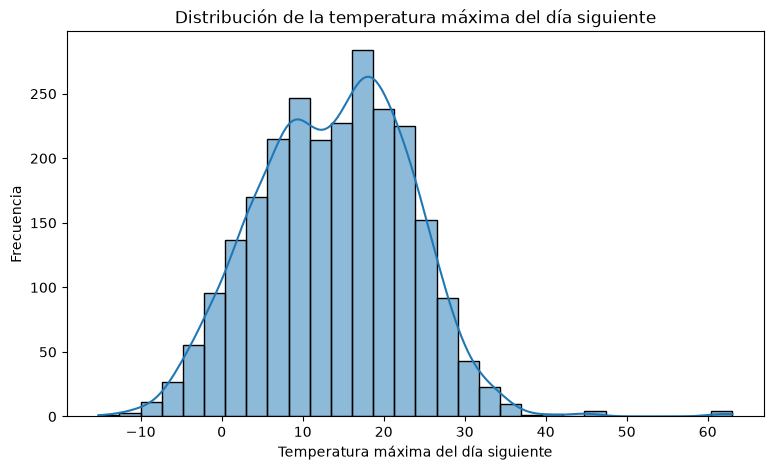

In [191]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="temp_max_manana",
    bins=30,
    kde=True
)

plt.title("Distribución de la temperatura máxima del día siguiente")
plt.xlabel("Temperatura máxima del día siguiente")
plt.ylabel("Frecuencia")
plt.show()

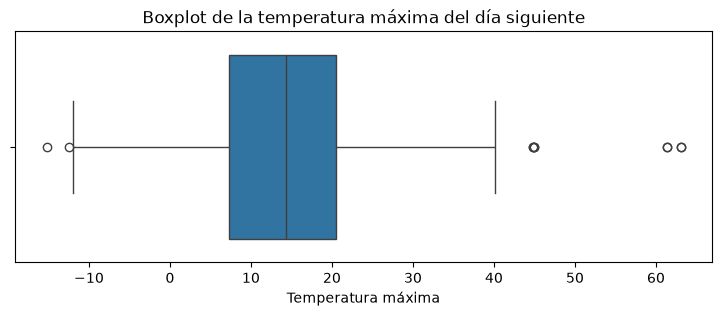

In [192]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    data=data,
    x="temp_max_manana"
)

plt.title("Boxplot de la temperatura máxima del día siguiente")
plt.xlabel("Temperatura máxima")
plt.show()

**Interpretación:**  
[Comentar forma, asimetría, dispersión y posibles valores atípicos.]

## 4.4 Relaciones entre variables

In [193]:
datos_numericos = data.select_dtypes(include="number")

correlaciones_objetivo = (
    datos_numericos
    .corr()["temp_max_manana"]
    .drop("temp_max_manana")
    .sort_values(key=lambda valores: valores.abs(), ascending=False)
)

correlaciones_objetivo

humedad_desv         0.571459
humedad_min         -0.203226
presion_desv        -0.199890
dia_del_anio         0.165812
humedad_max         -0.155211
presion_min          0.141860
humedad_media       -0.098139
anio                 0.092718
presion_max          0.070861
viento_desv          0.040129
viento_min          -0.039749
viento_media        -0.035994
presion_media       -0.032249
viento_max           0.031348
rafaga_max           0.030527
registros_del_dia    0.025923
rafaga_media        -0.024158
viento_norte        -0.020881
rafaga_min          -0.019087
viento_este          0.015941
direccion_viento     0.007824
rafaga_desv         -0.007027
Name: temp_max_manana, dtype: float64

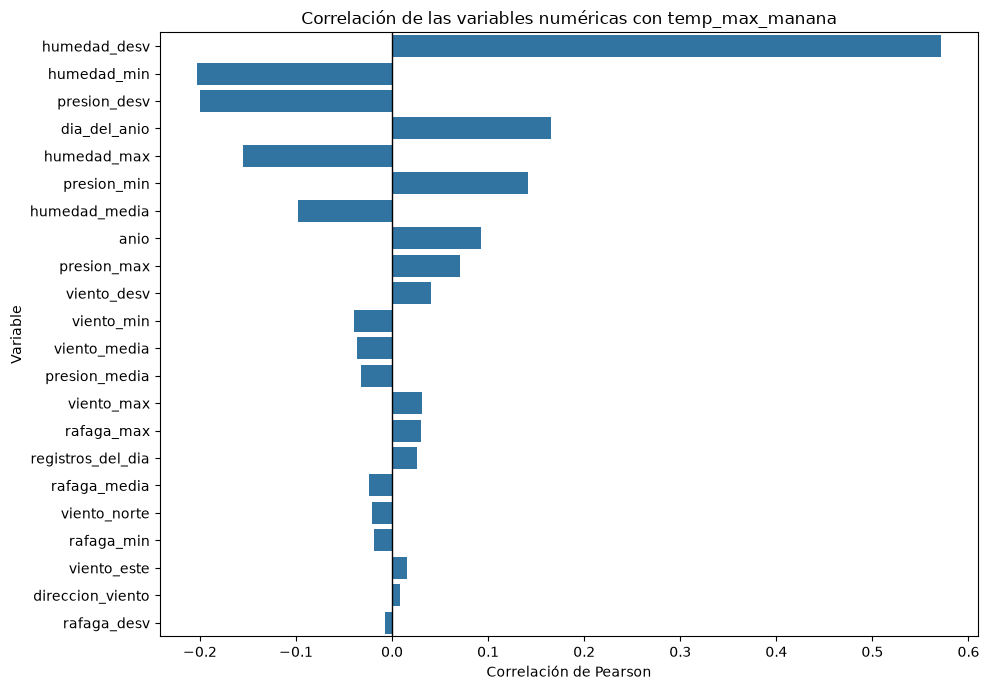

In [194]:
tabla_correlaciones = (
    correlaciones_objetivo
    .rename_axis("variable")
    .reset_index(name="correlacion")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=tabla_correlaciones,
    x="correlacion",
    y="variable"
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Correlación de las variables numéricas con temp_max_manana")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [195]:
variables_mayor_correlacion = (
    tabla_correlaciones
    .head(4)["variable"]
    .tolist()
)

variables_mayor_correlacion

['humedad_desv', 'humedad_min', 'presion_desv', 'dia_del_anio']

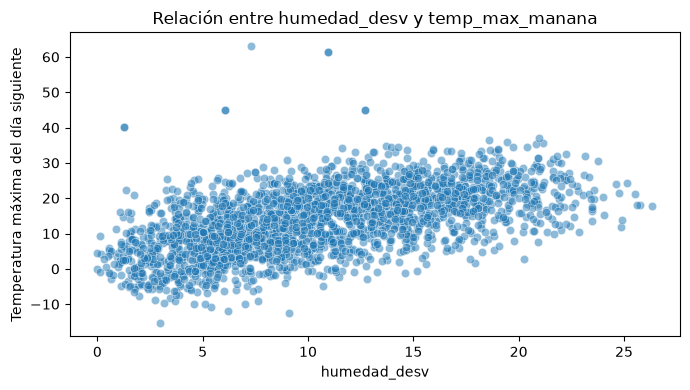

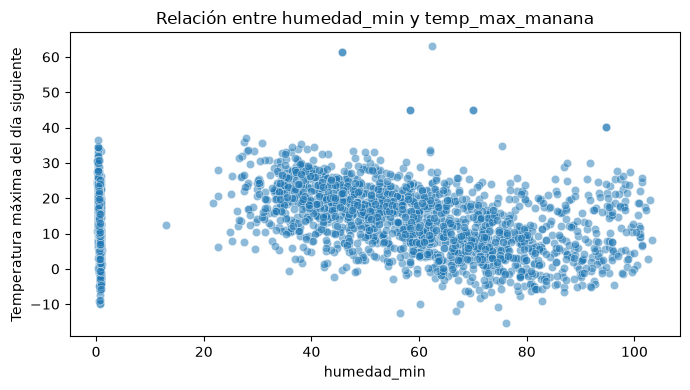

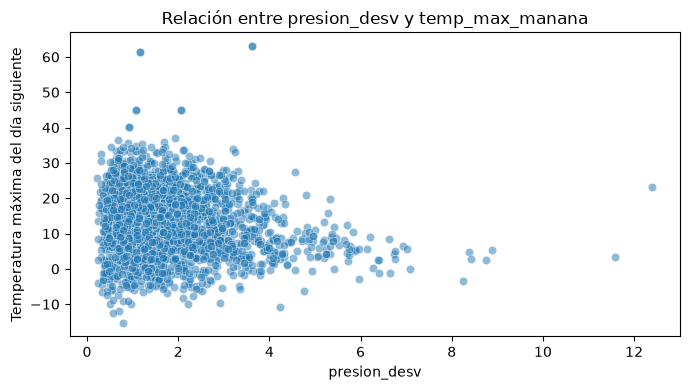

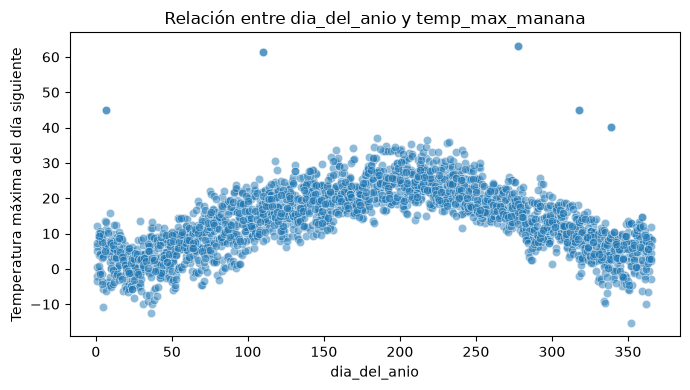

In [196]:
for variable in variables_mayor_correlacion:
    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=data,
        x=variable,
        y="temp_max_manana",
        alpha=0.5
    )

    plt.title(f"Relación entre {variable} y temp_max_manana")
    plt.xlabel(variable)
    plt.ylabel("Temperatura máxima del día siguiente")
    plt.tight_layout()
    plt.show()

**Interpretación:**  
[Identificar relaciones potencialmente predictivas, redundancias y patrones estacionales.]

# 5. Evaluación de la calidad de los datos

## 5.1 Completitud

In [197]:
# cantidad y porcentaje de valores ausentes por variable.
resumen_ausentes = pd.DataFrame({
    "valores_ausentes": data.isna().sum(),
    "porcentaje_ausente": data.isna().mean() * 100
})

resumen_ausentes = resumen_ausentes.sort_values(
    by="porcentaje_ausente",
    ascending=False
)

resumen_ausentes

,valores_ausentes,porcentaje_ausente
temp_max_manana,95,3.687888
viento_min,91,3.532609
estacion_anio,88,3.416149
mes,88,3.416149
anio,86,3.338509
humedad_max,86,3.338509
viento_media,86,3.338509
viento_max,81,3.144410
humedad_min,80,3.105590
viento_norte,80,3.105590


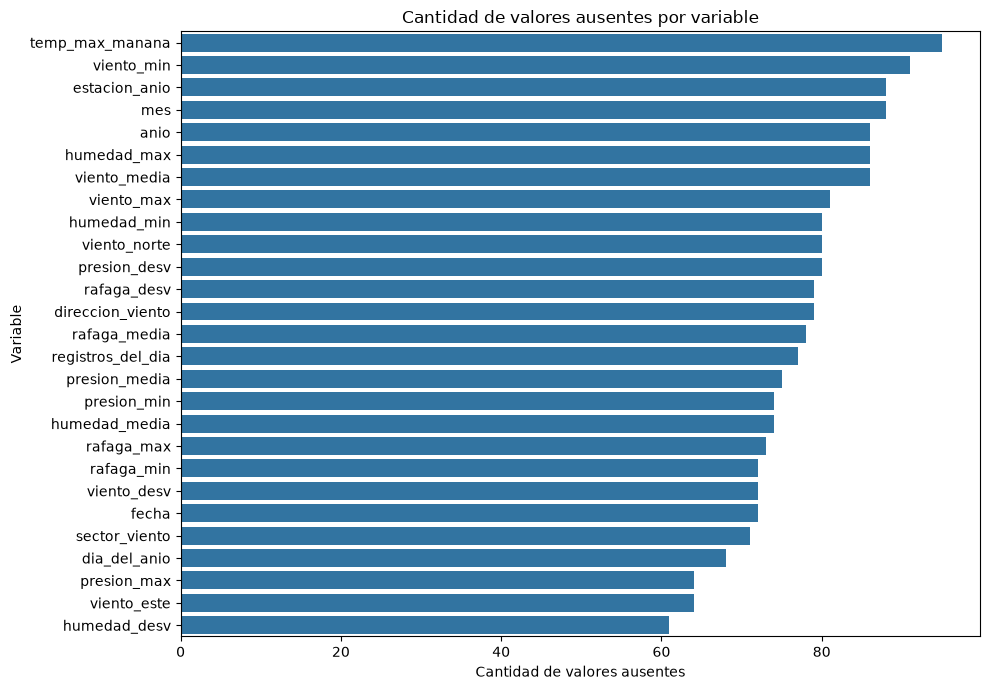

In [198]:
ausentes_grafico = resumen_ausentes[
    resumen_ausentes["valores_ausentes"] > 0
]

plt.figure(figsize=(10, 7))

sns.barplot(
    data=ausentes_grafico,
    x="valores_ausentes",
    y=ausentes_grafico.index
)

plt.title("Cantidad de valores ausentes por variable")
plt.xlabel("Cantidad de valores ausentes")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

**Hallazgos y decisión:**  
[Explicar qué variables tienen ausencias y cómo se tratarán. Diferenciar ausencias en predictores y en la variable objetivo.]

## 5.2 Unicidad

In [199]:
cantidad_duplicados = data.duplicated().sum()
print("Cantidad de filas duplicadas:", cantidad_duplicados)

Cantidad de filas duplicadas: 4


In [200]:
duplicados_completos = data.duplicated(keep=False)

data[duplicados_completos].sort_values(
    by="fecha"
)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412


In [201]:
fechas_repetidas = (
    data["fecha"].notna()
    & data.duplicated(subset=["fecha"], keep=False)
)

print("Filas involucradas en fechas repetidas:",fechas_repetidas.sum())

print("Cantidad de fechas diferentes repetidas:", data.loc[fechas_repetidas, "fecha"].nunique())

data[fechas_repetidas].sort_values(by="fecha")

Filas involucradas en fechas repetidas: 36
Cantidad de fechas diferentes repetidas: 18


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000


In [202]:
frecuencia_fechas = data["fecha"].value_counts()

frecuencia_fechas[
    frecuencia_fechas > 1
]

fecha
2009-01-22    2
2009-03-05    2
2009-05-02    2
2009-12-08    2
2010-08-14    2
2010-10-25    2
2012-10-04    2
2012-10-06    2
2012-11-13    2
2012-11-22    2
2013-01-02    2
2013-02-08    2
2013-04-20    2
2013-05-29    2
2015-01-07    2
2015-02-03    2
2015-05-11    2
2015-12-07    2
Name: count, dtype: int64

**Hallazgos y decisión:**  
[Justificar si se eliminan, conservan o consolidan registros.]

## 5.3 Consistencia

In [203]:
variables_categoricas = [
    "estacion_anio",
    "mes",
    "sector_viento"
]

for variable in variables_categoricas:
    print(f"\nVariable: {variable}")
    print(data[variable].value_counts(dropna=False))


Variable: estacion_anio
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Variable: mes
mes
May           127
August        125
July          123
January       120
March         118
             .

In [204]:
fecha_convertida = pd.to_datetime(
    data["fecha"],
    errors="coerce"
)

fechas_invalidas = (
    data["fecha"].notna()
    & fecha_convertida.isna()
)

print(
    "Fechas presentes que no pudieron convertirse:",
    fechas_invalidas.sum()
)

Fechas presentes que no pudieron convertirse: 0


In [205]:
registros_con_fecha_anio = (
    fecha_convertida.notna()
    & data["anio"].notna()
)

anio_inconsistente = (
    registros_con_fecha_anio
    & (fecha_convertida.dt.year != data["anio"])
)

print(
    "Registros donde fecha y anio no coinciden:",
    anio_inconsistente.sum()
)

Registros donde fecha y anio no coinciden: 0


**Hallazgos y decisión:**  
[Documentar inconsistencias y su corrección.]

## 5.4 Validez

In [206]:
columnas_revision = [
    "presion_min",
    "presion_media",
    "presion_max",
    "humedad_min",
    "humedad_media",
    "humedad_max",
    "viento_min",
    "viento_media",
    "viento_max",
    "rafaga_min",
    "rafaga_media",
    "rafaga_max",
    "direccion_viento",
    "registros_del_dia",
    "dia_del_anio"
]

data[columnas_revision].describe().T

,count,mean,std,min,25%,50%,75%,max
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_max,2495.0,7.647484,6.785897,0.000000,3.370000,5.051746,9.630000,45.108000
rafaga_min,2504.0,-2.639322,199.861693,-9999.000000,0.440000,0.660000,1.120000,19.895916


In [207]:
direccion_fuera_rango = data[
    data["direccion_viento"].notna()
    & ~data["direccion_viento"].between(0, 360)
]

print("Registros con dirección del viento fuera del rango:", direccion_fuera_rango.shape[0])

dia_fuera_rango = data[
    data["dia_del_anio"].notna()
    & ~data["dia_del_anio"].between(1, 366)
]

print("Registros con día del año fuera del rango:",dia_fuera_rango.shape[0])

registros_dia_fuera_rango = data[
    data["registros_del_dia"].notna()
    & ~data["registros_del_dia"].between(1, 144)
]

print("Registros del día fuera del rango:",registros_dia_fuera_rango.shape[0])

registros_dia_fuera_rango


Registros con dirección del viento fuera del rango: 0
Registros con día del año fuera del rango: 0
Registros del día fuera del rango: 4


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
546,2010-07-01,990.4292,989.100000,992.06,0.8498,0.603077,37.5100,89.4,17.2378,1.4374,...,0.6590,0.2537,21.0579,287.0,2010.0,182.0,verano,august,N,30.61
547,2010-07-02,990.1361,988.920000,990.84,0.6349,0.546587,0.3367,85.4,17.2655,1.8548,...,0.3600,1.1351,72.4017,145.0,2010.0,183.0,East,JULY,E,31.30
1904,2014-03-20,990.3983,997.040631,984.78,3.6080,0.004663,NaN,83.1,17.4491,3.6486,...,-3.4513,-0.2815,184.6636,222.0,2014.0,79.0,Estacion_Desconocida,Nov,S,19.92
1905,2014-03-21,982.6692,979.960000,984.97,1.5063,47.902900,36.1600,78.3,9.2391,4.9416,...,-4.1114,-2.3344,209.5877,249.0,2014.0,80.0,VERANO_INVIERNO,March,SO,11.57


In [208]:
presion_invalida = data[
    data[
        ["presion_min", "presion_media", "presion_max"]
    ].notna().all(axis=1)
    &
    (
        (data["presion_min"] > data["presion_media"])
        |
        (data["presion_media"] > data["presion_max"])
    )
]

print("Registros con orden inválido en presión:",presion_invalida.shape[0])

presion_invalida[
    ["presion_min", "presion_media", "presion_max"]
]

Registros con orden inválido en presión: 123


,presion_min,presion_media,presion_max
21,971.480000,9784.1150,983.54
43,994.906458,989.2739,988.44
44,1003.735938,994.9869,989.00
56,997.729414,990.5860,985.86
70,998.971077,992.2961,987.30
...,...,...,...
2540,1001.974454,999.4644,998.12
2561,985.610000,9939.9180,1001.18
2562,986.970000,9928.7720,998.17
2563,971.480000,9784.1150,983.54


In [209]:
humedad_invalida = data[
    data[
        ["humedad_min", "humedad_media", "humedad_max"]
    ].notna().all(axis=1)
    &
    (
        (data["humedad_min"] > data["humedad_media"])
        |
        (data["humedad_media"] > data["humedad_max"])
    )
]

print("Registros con orden inválido en humedad:",humedad_invalida.shape[0])

humedad_invalida[
    ["humedad_min", "humedad_media", "humedad_max"]
]

Registros con orden inválido en humedad: 280


,humedad_min,humedad_media,humedad_max
1,86.600000,0.920868,96.30
8,0.928437,0.839762,59.98
15,102.543211,92.759700,81.50
17,67.980000,0.827548,94.30
22,58.670000,0.780708,91.10
...,...,...,...
2530,89.340698,73.761000,63.44
2534,72.200000,0.900146,98.50
2535,71.300000,0.797528,86.00
2540,76.400000,0.891076,95.50


In [210]:
viento_invalido = data[
    data[
        ["viento_min", "viento_media", "viento_max"]
    ].notna().all(axis=1)
    &
    (
        (data["viento_min"] > data["viento_media"])
        |
        (data["viento_media"] > data["viento_max"])
    )
]

print("Registros con orden inválido en viento:",viento_invalido.shape[0])

viento_invalido[
    ["viento_min", "viento_media", "viento_max"]
]

Registros con orden inválido en viento: 152


,viento_min,viento_media,viento_max
17,34.953763,10.70604,0.684000
22,12.536035,5.10390,1.137109
32,9.119714,1.48330,0.037282
103,23.568189,5.45436,0.000000
120,9.008852,1.56780,0.070000
...,...,...,...
2466,4.807191,1.07060,0.111847
2490,20.850462,5.14080,0.469756
2499,21.364477,2.92392,0.432000
2510,7.495023,2.63260,0.577875


In [211]:
rafaga_invalida = data[
    data[
        ["rafaga_min", "rafaga_media", "rafaga_max"]
    ].notna().all(axis=1)
    &
    (
        (data["rafaga_min"] > data["rafaga_media"])
        |
        (data["rafaga_media"] > data["rafaga_max"])
    )
]

print("Registros con orden inválido en ráfaga:",rafaga_invalida.shape[0])

rafaga_invalida[
    ["rafaga_min", "rafaga_media", "rafaga_max"]
]

Registros con orden inválido en ráfaga: 134


,rafaga_min,rafaga_media,rafaga_max
33,4.271407,0.9710,0.236121
35,6.672666,2.8342,0.932056
57,10.078922,4.2082,1.500000
78,11.031436,3.4549,0.500000
95,7.744997,1.9045,0.250000
...,...,...,...
2538,9.180290,1.5524,0.240000
2546,2.980000,9.9197,8.854537
2548,10.186582,3.0527,0.680000
2554,10.479462,3.4318,0.640000


**Hallazgos y decisión:**  
[Distinguir entre un valor extremo válido y un error de calidad. Justificar cualquier corrección o eliminación.]

## 5.5 Resumen de calidad

| Problema | Variables afectadas | Evidencia | Decisión | Justificación |
|---|---|---|---|---|
| Valores ausentes | [Completar] | [Completar] | [Completar] | [Completar] |
| Duplicados | [Completar] | [Completar] | [Completar] | [Completar] |
| Inconsistencias | [Completar] | [Completar] | [Completar] | [Completar] |
| Valores inválidos | [Completar] | [Completar] | [Completar] | [Completar] |

# 6. Preparación de los datos

## 6.1 Limpieza determinística común

Antes de comparar los modelos se aplican las mismas reglas de calidad a los datos: normalización del texto, eliminación de duplicados exactos, conversión de valores centinela a ausentes, corrección de errores evidentes de escala y validación de relaciones como `mínimo <= media <= máximo`. Las categorías equivalentes del sector del viento se unifican mediante un diccionario.

Los límites usados son conservadores y se apoyan en las unidades del diccionario, las restricciones físicas y los valores observados durante la exploración: presión entre 900 y 1100 mbar, humedad expresada como porcentaje, máximo de 144 registros diarios y temperatura objetivo entre -30 y 40 °C. Los valores que incumplen estas reglas se convierten en ausentes para que su imputación se aprenda únicamente con entrenamiento dentro del pipeline. No se calculan aquí medias, medianas ni parámetros de escalado.

Las fechas repetidas se resuelven después de aplicar las reglas anteriores, cuando los valores inválidos ya fueron convertidos en ausentes. Para cada fecha conflictiva se conserva la fila con menos predictores ausentes; si hay empate, se eliminan todas las filas de esa fecha porque no existe un criterio objetivo para escoger una. Si dos registros son completamente idénticos, se conserva una sola copia.

In [212]:
print("Dimensiones originales:", data.shape)

data["fecha"] = pd.to_datetime(
    data["fecha"],
    errors="coerce"
)

print(data["fecha"].dtype)
print("Fechas ausentes o inválidas:",data["fecha"].isna().sum())

columnas_categoricas_texto = ["estacion_anio","mes"]

for columna in columnas_categoricas_texto:
    data[columna] = (
        data[columna]
        .astype("string")
        .str.strip()
        .str.lower()
    )

data["sector_viento"] = (
    data["sector_viento"]
    .astype("string")
    .str.strip()
    .str.upper()
)

for columna in [
    "estacion_anio",
    "mes",
    "sector_viento"
]:
    print(f"\n{columna}")
    print(data[columna].value_counts(dropna=False))

Dimensiones originales: (2576, 27)
datetime64[us]
Fechas ausentes o inválidas: 72

estacion_anio
estacion_anio
invierno                538
primavera               537
verano                  515
otono                   508
<NA>                     88
inverano                 71
estacion_desconocida     63
verano_invierno          60
east                     48
otoño                    23
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
invernio                 11
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64[pyarrow]

mes
mes
march         173
may           168
september     168
january       166
august        165
july          162
december      160
november      155
october       152
june          148
february      142
april         135
<NA>           88
enero          52
diciembre      32
mayo           

In [213]:
print(
    "Duplicados antes:",
    data.duplicated().sum()
)

data = data.drop_duplicates().copy()

print("Duplicados después:",data.duplicated().sum())

fechas_repetidas = (
    data["fecha"].notna()
    & data.duplicated(
        subset=["fecha"],
        keep=False
    )
)

print("Filas con fechas todavía repetidas:",fechas_repetidas.sum())

data[fechas_repetidas].sort_values("fecha")







Duplicados antes: 4
Duplicados después: 0
Filas con fechas todavía repetidas: 28


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,july,N,5.370000
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,july,N,5.956009
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,<NA>,20.890000
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,august,NE,19.500000
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,august,NE,19.500000
2562,2010-10-25,9928.772000,986.97000,998.17,3.4396,79.714900,NaN,94.3,9.2834,5.98716,...,-0.4272,-1.2591,251.2583,144.0,2010.0,298.0,otono,october,O,7.340000
662,2010-10-25,9928.772000,986.97000,998.17,3.4396,79.714900,62.7000,94.3,9.2834,5.98716,...,-0.4272,-1.2591,251.2583,144.0,2010.0,298.0,otono,october,O,7.340000


In [214]:
# valores físicamente imposibles

columnas_numericas_todas = data.select_dtypes(include="number").columns.tolist()

data[columnas_numericas_todas] = data[columnas_numericas_todas].mask(
    data[columnas_numericas_todas] <= -999
)

# Las desviaciones no pueden ser negativas
for columna in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
    data.loc[data[columna] < 0, columna] = np.nan

# Velocidades y ráfagas no pueden ser negativas
for columna in ["viento_min", "viento_media", "viento_max",
                "rafaga_min", "rafaga_media", "rafaga_max"]:
    data.loc[data[columna] < 0, columna] = np.nan

print(data[["rafaga_min", "rafaga_media", "rafaga_desv"]].describe().T)

               count      mean        std  min     25%     50%      75%  \
rafaga_min    2499.0  1.354389   2.402414  0.0  0.4400  0.6600  1.12000   
rafaga_media  2493.0  3.544525   1.470573  0.0  2.5123  3.2292  4.26480   
rafaga_desv   2239.0  3.223451  73.323348  0.0  1.1605  1.5453  2.09625   

                      max  
rafaga_min      19.895916  
rafaga_media    11.465200  
rafaga_desv   3471.027800  


In [215]:
# Errores de escala 
columnas_presion = ["presion_media", "presion_min", "presion_max"]

# Presión ~9900 mbar = error de factor 10 (rango físico en Jena: ~950-1050).
for columna in columnas_presion:
    mascara = data[columna] > 1100
    print(f"{columna}: {mascara.sum()} valores corregidos por factor 10")
    data.loc[mascara, columna] = data.loc[mascara, columna] / 10
    data.loc[~data[columna].between(900, 1100), columna] = np.nan

columnas_humedad = ["humedad_media", "humedad_min", "humedad_max"]

# Humedad expresada como fracción (0-1) en vez de porcentaje.
for columna in columnas_humedad:
    mascara = data[columna] <= 1.5
    print(f"{columna}: {mascara.sum()} valores reescalados de fracción a porcentaje")
    data.loc[mascara, columna] = data.loc[mascara, columna] * 100
    data.loc[data[columna] < 10, columna] = np.nan

# Máximo físico de mediciones de 10 minutos en un día.
data.loc[data["registros_del_dia"] > 144, "registros_del_dia"] = np.nan

presion_media: 5 valores corregidos por factor 10
presion_min: 0 valores corregidos por factor 10
presion_max: 0 valores corregidos por factor 10
humedad_media: 777 valores reescalados de fracción a porcentaje
humedad_min: 625 valores reescalados de fracción a porcentaje
humedad_max: 0 valores reescalados de fracción a porcentaje


In [216]:
# --- Coherencia de las desviaciones típicas ---
# La desviación típica intradía no puede exceder el máximo observado ese día.
pares_desviacion = [
    ("viento_desv", "viento_max"),
    ("rafaga_desv", "rafaga_max"),
]

for col_desv, col_max in pares_desviacion:
    incoherente = (
        data[[col_desv, col_max]].notna().all(axis=1)
        & (data[col_desv] > data[col_max])
    )
    print(f"{col_desv}: {incoherente.sum()} valores marcados como ausentes")
    data.loc[incoherente, col_desv] = np.nan

# La presión, la humedad y el viento tienen rangos acotados por construcción.
data.loc[data["presion_desv"] > 50, "presion_desv"] = np.nan
data.loc[~data["humedad_desv"].between(0, 50), "humedad_desv"] = np.nan

# El valor 3319.03 observado en viento_desv es un error evidente de registro.
# Se usa 50 m/s como límite superior conservador para una desviación intradía.
extremos_viento_desv = data["viento_desv"] > 50
print(f"viento_desv: {extremos_viento_desv.sum()} extremos adicionales marcados como ausentes")
data.loc[extremos_viento_desv, "viento_desv"] = np.nan

data[["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]].describe().T

viento_desv: 347 valores marcados como ausentes
rafaga_desv: 99 valores marcados como ausentes
viento_desv: 5 extremos adicionales marcados como ausentes


,count,mean,std,min,25%,50%,75%,max
presion_desv,2492.0,1.751818,1.215922,0.2269,0.898425,1.44460,2.254800,12.3975
humedad_desv,2511.0,10.608566,5.484215,0.0000,6.082100,10.19980,14.723850,26.3416
viento_desv,2148.0,1.112442,0.994109,0.0000,0.730600,0.97195,1.369825,40.9900
rafaga_desv,2140.0,1.672431,0.720202,0.0000,1.154450,1.54445,2.099700,6.0548


In [217]:
# --- Coherencia min <= media <= max ---
# Decisión: si el trío es incoherente, no sabemos cuál de los tres está mal.
# Se marcan los tres como ausentes y el imputador del pipeline los resuelve.
tripletas = {
    "presion": ["presion_min", "presion_media", "presion_max"],
    "humedad": ["humedad_min", "humedad_media", "humedad_max"],
    "viento":  ["viento_min", "viento_media", "viento_max"],
    "rafaga":  ["rafaga_min", "rafaga_media", "rafaga_max"],
}

for nombre, (col_min, col_med, col_max) in tripletas.items():
    incoherente = (
        data[[col_min, col_med, col_max]].notna().all(axis=1)
        & ((data[col_min] > data[col_med]) | (data[col_med] > data[col_max]))
    )
    print(f"{nombre}: {incoherente.sum()} tripletas marcadas como ausentes")
    data.loc[incoherente, [col_min, col_med, col_max]] = np.nan

presion: 117 tripletas marcadas como ausentes
humedad: 117 tripletas marcadas como ausentes
viento: 152 tripletas marcadas como ausentes
rafaga: 134 tripletas marcadas como ausentes


In [218]:
# --- Reconstrucción de mes y estación desde la fecha ---
# Reconstruir es más robusto que mapear 62 variantes de texto a mano.
data["mes_num"] = data["fecha"].dt.month
data["dia_del_anio"] = data["dia_del_anio"].fillna(data["fecha"].dt.dayofyear)
data["anio"] = data["anio"].fillna(data["fecha"].dt.year)

estaciones_hemisferio_norte = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}
data["estacion_reconstruida"] = data["mes_num"].map(estaciones_hemisferio_norte)

print(data["estacion_reconstruida"].value_counts(dropna=False))

estacion_reconstruida
primavera    636
verano       628
otono        619
invierno     617
NaN           72
Name: count, dtype: int64


In [219]:
# --- Armonización de sector_viento ---
mapa_sector = {
    "N": "N", "NORTH": "N", "NORTE": "N",
    "S": "S", "SOUTH": "S", "SUR": "S",
    "E": "E", "EAST": "E", "ESTE": "E",
    "O": "O", "WEST": "O", "OESTE": "O",
    "NE": "NE", "NORTHEAST": "NE", "NORESTE": "NE",
    "NO": "NO", "NORTHWEST": "NO", "NOROESTE": "NO",
    "SE": "SE", "SOUTHEAST": "SE", "SURESTE": "SE",
    "SO": "SO", "SOUTHWEST": "SO", "SUROESTE": "SO",
}
data["sector_viento"] = data["sector_viento"].map(mapa_sector)
print(data["sector_viento"].value_counts(dropna=False))

sector_viento
SO     774
S      580
NE     471
O      328
N      137
E       87
SE      72
NaN     71
NO      52
Name: count, dtype: int64


In [220]:
# --- valores imposibles y ausentes ---
# Récord histórico de Jena ~ 38-39 °C.
data.loc[~data["temp_max_manana"].between(-30, 40), "temp_max_manana"] = np.nan

filas_antes = data.shape[0]
data = data.dropna(subset=["temp_max_manana"]).copy()
print(f"Filas eliminadas por objetivo ausente: {filas_antes - data.shape[0]}")

# --- Resolución de fechas repetidas después de completar la limpieza ---
# La limpieza puede hacer que dos registros antes diferentes queden idénticos.
duplicados_identicos_generados = data.duplicated().sum()
data = data.drop_duplicates().copy()
print("Duplicados idénticos adicionales eliminados:", duplicados_identicos_generados)

columnas_completitud = [
    columna for columna in data.columns
    if columna not in ["fecha", "temp_max_manana"]
]

fechas_conflictivas = (
    data["fecha"].notna()
    & data.duplicated(subset=["fecha"], keep=False)
)

indices_eliminar = []
resumen_duplicados_fecha = []

for fecha, grupo in data.loc[fechas_conflictivas].groupby("fecha"):
    nulos_por_fila = grupo[columnas_completitud].isna().sum(axis=1)
    minimo_nulos = nulos_por_fila.min()
    mejores_indices = nulos_por_fila[nulos_por_fila == minimo_nulos].index

    if len(mejores_indices) == 1:
        indice_conservado = mejores_indices[0]
        indices_eliminar.extend(grupo.index.difference([indice_conservado]).tolist())
        decision = "Se conserva la fila más completa"
    else:
        indice_conservado = pd.NA
        indices_eliminar.extend(grupo.index.tolist())
        decision = "Empate: se eliminan todas"

    resumen_duplicados_fecha.append({
        "fecha": fecha,
        "filas_originales": len(grupo),
        "minimo_nulos_predictores": minimo_nulos,
        "indice_conservado": indice_conservado,
        "decision": decision,
    })

resumen_duplicados_fecha = pd.DataFrame(resumen_duplicados_fecha)
data = data.drop(index=indices_eliminar).copy()

print("Filas eliminadas para resolver fechas repetidas:", len(indices_eliminar))
print("Fechas válidas todavía repetidas:",
      data.loc[data["fecha"].notna(), "fecha"].duplicated().sum())
print("Dimensiones finales:", data.shape)

resumen_duplicados_fecha

Filas eliminadas por objetivo ausente: 103
Duplicados idénticos adicionales eliminados: 0
Filas eliminadas para resolver fechas repetidas: 16
Fechas válidas todavía repetidas: 0
Dimensiones finales: (2453, 29)


,fecha,filas_originales,minimo_nulos_predictores,indice_conservado,decision
0,2009-03-05,2,0,63,Se conserva la fila más completa
1,2009-05-02,2,0,2568,Se conserva la fila más completa
2,2009-12-08,2,2,341,Se conserva la fila más completa
3,2010-08-14,2,0,<NA>,Empate: se eliminan todas
4,2010-10-25,2,2,662,Se conserva la fila más completa
5,2012-10-06,2,0,2567,Se conserva la fila más completa
6,2012-11-22,2,3,<NA>,Empate: se eliminan todas
7,2013-01-02,2,2,2561,Se conserva la fila más completa
8,2013-05-29,2,0,<NA>,Empate: se eliminan todas
9,2015-02-03,2,0,<NA>,Empate: se eliminan todas


### Función para aplicar las mismas reglas a datos nuevos

El archivo final no tiene variable objetivo. Por eso se aplican las mismas correcciones a sus predictores, pero se conserva el número y el orden de sus filas.

In [221]:
def limpiar_predictores_nuevos(df):
    limpio = df.copy()

    # Se conserva el tratamiento de fecha ya definido, sin resolver duplicados por fecha.
    limpio["fecha"] = pd.to_datetime(limpio["fecha"], errors="coerce")
    for columna in ["estacion_anio", "mes"]:
        limpio[columna] = limpio[columna].astype("string").str.strip().str.lower()
    limpio["sector_viento"] = limpio["sector_viento"].astype("string").str.strip().str.upper()

    columnas_numericas = limpio.select_dtypes(include="number").columns
    limpio[columnas_numericas] = limpio[columnas_numericas].mask(limpio[columnas_numericas] <= -999)

    for columna in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
        limpio.loc[limpio[columna] < 0, columna] = np.nan
    for columna in ["viento_min", "viento_media", "viento_max",
                    "rafaga_min", "rafaga_media", "rafaga_max"]:
        limpio.loc[limpio[columna] < 0, columna] = np.nan

    for columna in ["presion_media", "presion_min", "presion_max"]:
        mascara = limpio[columna] > 1100
        limpio.loc[mascara, columna] = limpio.loc[mascara, columna] / 10
        limpio.loc[~limpio[columna].between(900, 1100), columna] = np.nan

    for columna in ["humedad_media", "humedad_min", "humedad_max"]:
        mascara = limpio[columna] <= 1.5
        limpio.loc[mascara, columna] = limpio.loc[mascara, columna] * 100
        limpio.loc[limpio[columna] < 10, columna] = np.nan

    limpio.loc[limpio["registros_del_dia"] > 144, "registros_del_dia"] = np.nan

    for col_desv, col_max in [("viento_desv", "viento_max"),
                              ("rafaga_desv", "rafaga_max")]:
        incoherente = (limpio[[col_desv, col_max]].notna().all(axis=1)
                       & (limpio[col_desv] > limpio[col_max]))
        limpio.loc[incoherente, col_desv] = np.nan

    limpio.loc[limpio["presion_desv"] > 50, "presion_desv"] = np.nan
    limpio.loc[~limpio["humedad_desv"].between(0, 50), "humedad_desv"] = np.nan
    limpio.loc[limpio["viento_desv"] > 50, "viento_desv"] = np.nan

    tripletas = {
        "presion": ["presion_min", "presion_media", "presion_max"],
        "humedad": ["humedad_min", "humedad_media", "humedad_max"],
        "viento": ["viento_min", "viento_media", "viento_max"],
        "rafaga": ["rafaga_min", "rafaga_media", "rafaga_max"],
    }
    for col_min, col_med, col_max in tripletas.values():
        incoherente = (limpio[[col_min, col_med, col_max]].notna().all(axis=1)
                       & ((limpio[col_min] > limpio[col_med])
                          | (limpio[col_med] > limpio[col_max])))
        limpio.loc[incoherente, [col_min, col_med, col_max]] = np.nan

    limpio["mes_num"] = limpio["fecha"].dt.month
    limpio["dia_del_anio"] = limpio["dia_del_anio"].fillna(limpio["fecha"].dt.dayofyear)
    limpio["anio"] = limpio["anio"].fillna(limpio["fecha"].dt.year)
    limpio["estacion_reconstruida"] = limpio["mes_num"].map(estaciones_hemisferio_norte)
    limpio["sector_viento"] = limpio["sector_viento"].map(mapa_sector)

    return limpio


data_test_limpio = limpiar_predictores_nuevos(data_test)
print("Filas originales del CSV final:", len(data_test))
print("Filas después de la limpieza:", len(data_test_limpio))
print("Se conservaron el orden y los índices:", data_test_limpio.index.equals(data_test.index))

Filas originales del CSV final: 364
Filas después de la limpieza: 364
Se conservaron el orden y los índices: True


## 6.2 Separación de predictores y variable objetivo

Una vez finalizada la limpieza común, se separan las variables del problema. La variable objetivo o dependiente es `temp_max_manana`, mientras que `X` conserva inicialmente las demás columnas como posibles predictoras. La selección de las características que utilizará cada modelo se realizará posteriormente dentro de su respectivo pipeline, lo que permite comparar estrategias de preparación diferentes sobre la misma información de partida.

In [222]:
target = "temp_max_manana"
X = data.drop(columns=[target]).copy()
y = data[target].copy()

print("X:", X.shape, "| y:", y.shape)
print("La variable objetivo está en X:", target in X.columns)
print("Valores ausentes en y:", y.isna().sum())

display(X.head())
display(y.head())

X: (2453, 28) | y: (2453,)
La variable objetivo está en X: False
Valores ausentes en y: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,mes_num,estacion_reconstruida
0,2009-01-01,999.1456,996.50,1000.87,1.3993,91.0860,87.500000,94.8,1.7650,0.7786,...,-0.0223,183.5308,143.0,2009.0,1.0,invierno,january,S,1.0,invierno
1,2009-01-02,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,...,0.3689,40.8436,144.0,2009.0,2.0,invierno,july,NE,1.0,invierno
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,...,-0.5268,216.9916,144.0,2009.0,3.0,invierno,january,SO,1.0,invierno
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,...,-1.0413,222.7419,144.0,2009.0,4.0,invierno,january,SO,1.0,invierno
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.8003,...,0.2874,6.2418,NaN,2009.0,5.0,east,january,N,1.0,invierno


0    -2.12
1    -0.82
2    -0.63
3    -1.44
4   -10.88
Name: temp_max_manana, dtype: float64

## 6.3 División entrenamiento/prueba

Los datos se dividen una sola vez en entrenamiento (**75 %**) y prueba interna (**25 %**). El conjunto de entrenamiento se utilizará para ajustar los pipelines y el conjunto de prueba para comparar su capacidad de generalización. Se fija `random_state=42` para obtener exactamente la misma partición en cada ejecución y garantizar una comparación reproducible entre modelos. Ambos modelos utilizarán los mismos índices de entrenamiento y prueba.

In [223]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)


In [224]:
print(f"Semilla utilizada: {RANDOM_STATE}")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

indices_compartidos = X_train.index.intersection(X_test.index)
print("Índices compartidos entre train y test:", len(indices_compartidos))

comparacion_objetivo = pd.DataFrame({
    "entrenamiento": y_train.describe(),
    "prueba": y_test.describe()
})

comparacion_objetivo

Semilla utilizada: 42
X_train: (1839, 28) | X_test: (614, 28)
y_train: (1839,) | y_test: (614,)
Índices compartidos entre train y test: 0


,entrenamiento,prueba
count,1839.000000,614.000000
mean,13.677749,13.918875
std,9.085856,8.726590
min,-15.230000,-12.470000
25%,7.020000,8.000000
50%,14.260000,14.440000
75%,20.420000,20.337500
max,37.010000,36.400000


# 7. Modelo 1 — [Nombre descriptivo]

## 7.1 Hipótesis y estrategia

**Hipótesis:** una regresión lineal sobre todas las variables numéricas disponibles, con imputación por mediana y estandarización, captura una parte razonable de la variabilidad de la temperatura máxima del día siguiente y sirve como línea base contra la cual medir cualquier mejora.

**Variables utilizadas:** todas las numéricas más las categóricas armonizadas que son estacion_reconstruida y sector_viento  

**Tratamiento de valores ausentes:** mediana para numéricas y moda para categóricas

**Transformaciones:** standardScaler en numéricas y OneHotEncoder(handle_unknown="ignore") en categóricas.

**Justificación:** el escalado no cambia el ajuste de una regresión lineal por MCO, pero pone los coeficientes en unidades comparables

## 7.2 Pipeline de preparación y modelado

In [90]:
# listas de variables numéricas y categóricas del modelo 1.
variables_numericas_m1 = X_train.select_dtypes(include="number").columns.tolist()
variables_categoricas_m1 = ["estacion_reconstruida", "sector_viento"]

print("Numéricas:", len(variables_numericas_m1))
print("Categóricas:", variables_categoricas_m1)

Numéricas: 23
Categóricas: ['estacion_reconstruida', 'sector_viento']


In [225]:
# ColumnTransformer y Pipeline del modelo 1.
transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preparacion_m1 = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico, variables_numericas_m1),
    ("categoricas", transformador_categorico, variables_categoricas_m1),
])

modelo_1 = Pipeline(steps=[
    ("preparacion", preparacion_m1),
    ("regresion", LinearRegression()),
])

modelo_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## 7.3 Entrenamiento

In [226]:
# TODO: ajustar el pipeline del modelo 1 únicamente con X_train e y_train.
modelo_1.fit(X_train, y_train)
print("Modelo 1 entrenado.")
print("Número de características tras la preparación:",
      modelo_1.named_steps["regresion"].coef_.shape[0])

Modelo 1 entrenado.
Número de características tras la preparación: 33


## 7.4 Evaluación en entrenamiento y prueba

In [228]:
# TODO: obtener predicciones de entrenamiento y prueba.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre):
    predicciones = {
        "Entrenamiento": (y_train, modelo.predict(X_train)),
        "Prueba": (y_test, modelo.predict(X_test)),
    }
    filas = []
    for conjunto, (reales, estimados) in predicciones.items():
        filas.append({
            "Modelo": nombre,
            "Conjunto": conjunto,
            "RMSE": np.sqrt(mean_squared_error(reales, estimados)),
            "MAE": mean_absolute_error(reales, estimados),
            "R2": r2_score(reales, estimados),
        })
    return pd.DataFrame(filas)

resultados_m1 = evaluar_modelo(modelo_1, X_train, y_train, X_test, y_test, "Modelo 1")
resultados_m1.round(4)


,Modelo,Conjunto,RMSE,MAE,R2
0,Modelo 1,Entrenamiento,5.0341,3.9853,0.6929
1,Modelo 1,Prueba,5.2739,4.1064,0.6342


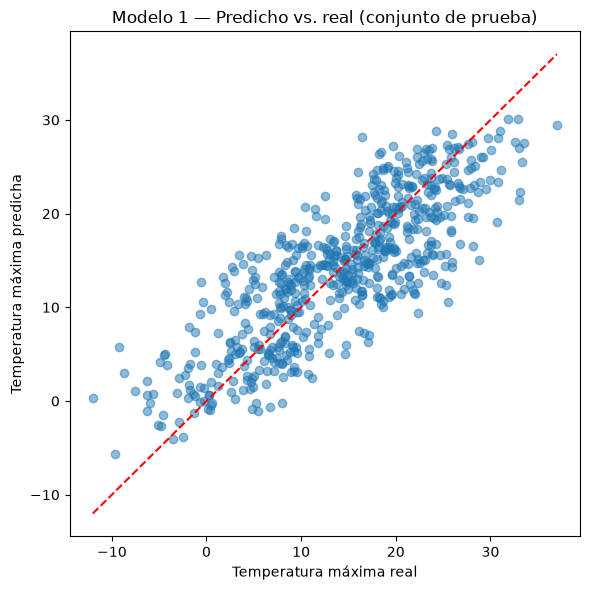

In [94]:
predicciones_test_m1 = modelo_1.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predicciones_test_m1, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Temperatura máxima real")
plt.ylabel("Temperatura máxima predicha")
plt.title("Modelo 1 — Predicho vs. real (conjunto de prueba)")
plt.tight_layout()
plt.show()

**Interpretación del modelo 1:**  
[Interpretar las métricas y comparar train contra test. Comentar capacidad de generalización.]

# 8. Modelo 2 — Regresión lineal con características temporales cíclicas

## 8.1 Diferencia respecto al modelo 1

**Cambio realizado:** se reemplazan `dia_del_anio`, `mes_num` y `estacion_reconstruida` por dos características cíclicas (`dia_seno` y `dia_coseno`). También se descarta `direccion_viento`, conservando `viento_norte`, `viento_este` y `sector_viento`. El estimador final continúa siendo `LinearRegression`.  

**Hipótesis:** representar el momento del año como un ciclo puede capturar mejor el comportamiento estacional de la temperatura y mejorar la generalización frente a utilizar el día como un número lineal.  

**Justificación:** el día 365 y el día 1 son cercanos en el calendario, aunque sus valores numéricos estén alejados. De manera similar, una dirección de 359° es cercana a 1°. La nueva preparación evita esas discontinuidades y elimina representaciones redundantes.

## 8.2 Preparación específica del modelo 2

In [229]:
def crear_caracteristicas_ciclicas(df):
    resultado = df.copy()
    angulo_anual = 2 * np.pi * resultado["dia_del_anio"] / 365.25
    resultado["dia_seno"] = np.sin(angulo_anual)
    resultado["dia_coseno"] = np.cos(angulo_anual)
    return resultado


# La justificación se calcula únicamente con el conjunto de entrenamiento.
X_train_ciclico = crear_caracteristicas_ciclicas(X_train)
correlaciones_temporales_m2 = (
    X_train_ciclico[["dia_del_anio", "dia_seno", "dia_coseno"]]
    .corrwith(y_train)
    .rename("correlacion_con_objetivo")
    .sort_values(key=lambda valores: valores.abs(), ascending=False)
)

correlaciones_temporales_m2

dia_coseno     -0.813749
dia_seno       -0.206595
dia_del_anio    0.157918
Name: correlacion_con_objetivo, dtype: float64

In [230]:
variables_numericas_m2 = X_train.select_dtypes(include="number").columns.tolist()

# Se reemplazan las representaciones lineales o redundantes por dia_seno y dia_coseno.
variables_descartadas_m2 = ["dia_del_anio", "mes_num", "direccion_viento"]
variables_numericas_m2 = [
    variable for variable in variables_numericas_m2
    if variable not in variables_descartadas_m2
]
variables_numericas_m2 += ["dia_seno", "dia_coseno"]

# La estación se omite porque su información ya está representada por el ciclo anual.
variables_categoricas_m2 = ["sector_viento"]

print("Numéricas modelo 2:", variables_numericas_m2)
print("Categóricas modelo 2:", variables_categoricas_m2)

Numéricas modelo 2: ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'dia_seno', 'dia_coseno']
Categóricas modelo 2: ['sector_viento']


## 8.3 Pipeline de preparación y modelado

In [231]:
transformador_numerico_m2 = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

transformador_categorico_m2 = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preparacion_m2 = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico_m2, variables_numericas_m2),
    ("categoricas", transformador_categorico_m2, variables_categoricas_m2),
])

modelo_2 = Pipeline(steps=[
    ("ingenieria_ciclica", FunctionTransformer(crear_caracteristicas_ciclicas, validate=False)),
    ("preparacion", preparacion_m2),
    ("regresion", LinearRegression()),
])

modelo_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ingenieria_ciclica', ...), ('preparacion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001F7EE51D7A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defaul

## 8.4 Entrenamiento

In [232]:
modelo_2.fit(X_train, y_train)
print("Modelo 2 entrenado.")
print("Número de características tras la preparación:",
      modelo_2.named_steps["regresion"].coef_.shape[0])

Modelo 2 entrenado.
Número de características tras la preparación: 29


## 8.5 Evaluación en entrenamiento y prueba

,Modelo,Conjunto,RMSE,MAE,R2
0,Modelo 2,Entrenamiento,4.0454,3.2298,0.8017
1,Modelo 2,Prueba,4.2411,3.4286,0.7634


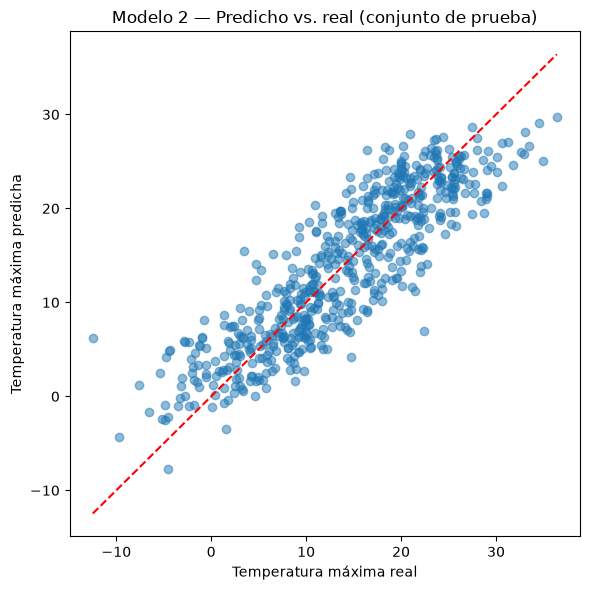

In [233]:
resultados_m2 = evaluar_modelo(
    modelo_2, X_train, y_train, X_test, y_test, "Modelo 2"
)
display(resultados_m2.round(4))

predicciones_test_m2 = modelo_2.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predicciones_test_m2, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Temperatura máxima real")
plt.ylabel("Temperatura máxima predicha")
plt.title("Modelo 2 — Predicho vs. real (conjunto de prueba)")
plt.tight_layout()
plt.show()

**Interpretación del modelo 2:**  
Después de ejecutar las celdas, se deben comparar sus métricas de prueba con las del modelo 1. Una reducción de RMSE y MAE junto con un aumento de R² respaldaría la utilidad de la representación cíclica. También se debe revisar que la diferencia entre entrenamiento y prueba no aumente considerablemente, pues esto indicaría menor capacidad de generalización.

# 9. Comparación y selección del mejor modelo

In [54]:
# TODO: construir una tabla comparativa con RMSE, MAE y R² de test.
# Las filas deben representar los modelos y las columnas las métricas.

| Modelo | Preparación principal | RMSE test | MAE test | R² test |
|---|---|---:|---:|---:|
| Modelo 1 | [Completar] | [Completar] | [Completar] | [Completar] |
| Modelo 2 | [Completar] | [Completar] | [Completar] | [Completar] |

## 9.1 Modelo seleccionado

**Mejor modelo:** [Completar.]  
**Criterio principal:** RMSE sobre el conjunto de prueba.  
**Justificación:** [Interpretar conjuntamente RMSE, MAE, R² y diferencia entre entrenamiento y prueba.]

# 10. Interpretación y verificación de supuestos

Las siguientes verificaciones se realizarán sobre el modelo seleccionado.

## 10.1 Coeficientes e importancia de variables

In [55]:
# TODO: recuperar los nombres de las características transformadas.
# TODO: construir una tabla con variable, coeficiente y valor absoluto del coeficiente.
# TODO: ordenar la tabla según el criterio de importancia seleccionado.

**Interpretación:**  
[Interpretar signo y magnitud teniendo en cuenta el escalado y la codificación utilizados. Relacionar los resultados con el contexto meteorológico.]

## 10.2 Residuales

In [56]:
# TODO: calcular predicciones y residuales del conjunto utilizado para diagnosticar supuestos.

## 10.3 Multicolinealidad

In [57]:
# TODO: calcular y presentar el VIF de las variables del modelo seleccionado.

**Conclusión sobre multicolinealidad:**  
[Indicar si se cumple el supuesto y qué implica para la interpretación de los coeficientes.]

## 10.4 Normalidad de los errores

In [58]:
# TODO: generar histograma y Q-Q plot de los residuales.
# TODO: aplicar la prueba estadística trabajada en clase.

**Conclusión sobre normalidad:**  
[Interpretar el gráfico y el p-value. No limitarse a indicar si p es mayor o menor que 0.05.]

## 10.5 Homocedasticidad

In [59]:
# TODO: graficar residuales contra valores ajustados.
# TODO: aplicar la prueba de Breusch-Pagan.

**Conclusión sobre homocedasticidad:**  
[Interpretar evidencia gráfica y prueba estadística.]

## 10.6 Independencia de los errores

In [60]:
# TODO: evaluar independencia con Durbin-Watson y una visualización pertinente.

**Conclusión sobre independencia:**  
[Interpretar el resultado considerando que las observaciones tienen una dimensión temporal.]

## 10.7 Linealidad

In [61]:
# TODO: evaluar la linealidad con las visualizaciones y la prueba trabajadas en clase.

**Conclusión sobre linealidad:**  
[Interpretar los resultados y sus consecuencias.]

## 10.8 Resumen de supuestos

| Supuesto | Evidencia utilizada | Resultado | ¿Se cumple? | Consecuencia |
|---|---|---|---|---|
| Multicolinealidad | VIF | [Completar] | [Completar] | [Completar] |
| Normalidad | Q-Q plot y prueba | [Completar] | [Completar] | [Completar] |
| Homocedasticidad | Residuales y Breusch-Pagan | [Completar] | [Completar] | [Completar] |
| Independencia | Durbin-Watson | [Completar] | [Completar] | [Completar] |
| Linealidad | Gráficos y prueba | [Completar] | [Completar] | [Completar] |

# 11. Análisis de resultados

## 11.1 Coeficientes del mejor modelo

[Responder: ¿cuáles fueron los coeficientes obtenidos y cómo deben interpretarse? Hacer referencia a la tabla calculada.]

## 11.2 Comparación del rendimiento

[Responder: ¿cuál modelo obtuvo el mejor rendimiento en test y qué significan sus valores de RMSE, MAE y R²?]

## 11.3 Variables seleccionadas e interpretación contextual

[Responder: ¿qué variables fueron seleccionadas, cómo se relacionan con la temperatura máxima y cómo podría utilizarse este conocimiento para tomar decisiones?]

## 11.4 Representación matemática de la regresión lineal

La forma general del modelo es:

$$
\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}
$$

[Adaptar la ecuación a las variables finales. Explicar el método utilizado para estimar los coeficientes y el proceso de solución.]

## 11.5 Posibles sesgos

### Sesgo 1 — [Nombre]
[Definición, causa en este caso y posible consecuencia.]

### Sesgo 2 — [Nombre]
[Definición, causa en este caso y posible consecuencia.]

### Estrategias de mitigación
[Explicar cómo podrían detectarse o reducirse.]

# 12. Entrenamiento final y predicciones

## 12.1 Verificación de compatibilidad con los datos no etiquetados

In [62]:
# TODO: comprobar columnas, tipos y orden entre entrenamiento y datos no etiquetados.

## 12.2 Ajuste final del pipeline seleccionado

In [63]:
# TODO: después de seleccionar el modelo, ajustarlo con todos los datos etiquetados disponibles.

## 12.3 Generación y exportación de predicciones

In [64]:
# TODO: predecir temp_max_manana para los datos no etiquetados.
# TODO: agregar la columna al archivo base sin alterar el orden de sus filas.
# TODO: exportar el CSV con el nombre solicitado por el curso.

In [65]:
# TODO: verificar cantidad de predicciones, valores ausentes y primeras filas del archivo final.

# 13. Conclusiones

1. **Resultado predictivo principal:** [Completar.]
2. **Variables meteorológicas más relevantes:** [Completar.]
3. **Calidad y limitaciones de los datos:** [Completar.]
4. **Cumplimiento de supuestos:** [Completar.]
5. **Recomendación para AlpesPlanck:** [Completar.]

# 14. Guion del video

Duración máxima: 3 minutos. Audiencia: ingeniero de machine learning que lidera el grupo de AlpesPlanck.

| Tiempo aproximado | Contenido | Responsable |
|---|---|---|
| 0:00–0:25 | Problema, datos y objetivo | [Completar] |
| 0:25–0:55 | Hallazgos de exploración y calidad | [Completar] |
| 0:55–1:35 | Preparación y modelos comparados | [Completar] |
| 1:35–2:05 | Métricas y selección del mejor modelo | [Completar] |
| 2:05–2:35 | Variables importantes y supuestos | [Completar] |
| 2:35–3:00 | Conclusiones, limitaciones y recomendación | [Completar] |

# 15. Uso de herramientas de IA generativa

## 15.1 Declaración de uso

**Herramienta utilizada:** [Completar.]  
**Tipos de uso:** [Ayuda conceptual, estructura inicial, depuración, explicación teórica, redacción u otros.]

## 15.2 Prompts principales

1. [Prompt o resumen del prompt.]
2. [Prompt o resumen del prompt.]
3. [Agregar los prompts que influyeron directamente en el entregable.]

## 15.3 Análisis crítico del resultado

[Responder al menos dos preguntas exigidas por el curso:]

- ¿Qué partes del contenido generado fueron correctas y útiles?
- ¿Qué errores, imprecisiones o limitaciones se identificaron?
- ¿Qué decisiones técnicas se modificaron y por qué?
- ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta?

## 15.4 Aportes propios de los estudiantes

[Explicar qué fue desarrollado, verificado, modificado o decidido por los integrantes y qué aprendizajes obtuvieron.]

---

## Lista de verificación antes de entregar

- [ ] Todas las decisiones de preparación están justificadas.
- [ ] Se comparan al menos dos modelos con el mismo conjunto de prueba.
- [ ] La tabla incluye RMSE, MAE y R² de test.
- [ ] Se presenta la importancia de las variables del mejor modelo.
- [ ] Se verifican e interpretan los supuestos de regresión lineal.
- [ ] Se responden las cinco preguntas de análisis de resultados.
- [ ] El archivo de predicciones conserva todas las filas y el orden original.
- [ ] Todas las celdas están ejecutadas y muestran sus resultados.
- [ ] El notebook se exportó también a HTML.
- [ ] Se documentó el uso de IA generativa.
- [ ] El video dura máximo 3 minutos.